In [1]:
from rdkit import Chem
from pathlib import Path

from stereomolgraph import MolGraph, CondensedReactionGraph, StereoMolGraph, StereoCondensedReactionGraph
from stereomolgraph.stereodescriptors import Tetrahedral
from stereomolgraph.ipython import View2D

from stereomolgraph.experimental import generate_fleeting_stereoisomers

from crnviewer.crn import CRGContainer, SCRGContainer
from crnviewer.ipython import display_crg_container_with_images
from crnviewer.rdalign import aligned_renderer_from_container

from crnviewer.ipython import build_builder_from_container
from crnviewer.html import cybuilder_html

View2D.show_atom_numbers = False
View2D.generate_bond_orders = True

In [ ]:
rn = CRGContainer()

In [3]:
methylamine_rdmol = Chem.AddHs(Chem.MolFromSmiles("NC"))
phosgene_rdmol = Chem.AddHs(Chem.MolFromSmiles("ClC(Cl)=O"))

In [4]:
met_am_phos_rdmol = Chem.CombineMols(methylamine_rdmol, phosgene_rdmol)
hcl_rdmol = Chem.AddHs(Chem.MolFromSmiles("Cl"))

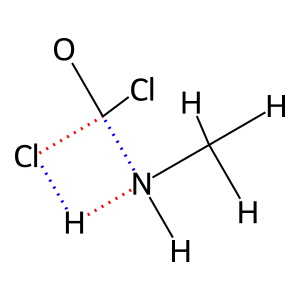

In [13]:
crg1 = CondensedReactionGraph.from_rdmol(met_am_phos_rdmol)

crg1.add_formed_bond(0, 8)
crg1.add_formed_bond(7, 2)
crg1.add_broken_bond(7,8)
crg1.add_broken_bond(0,2)

rn.add(crg1)
crg1

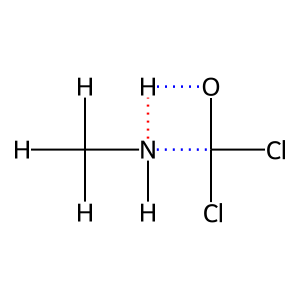

In [14]:
crg_aminol = StereoCondensedReactionGraph.from_rdmol(met_am_phos_rdmol)
crg_aminol.add_formed_bond(0, 8)
crg_aminol.add_formed_bond(10,3)
crg_aminol.add_broken_bond(3,0)

rn.add(crg_aminol)
crg_aminol

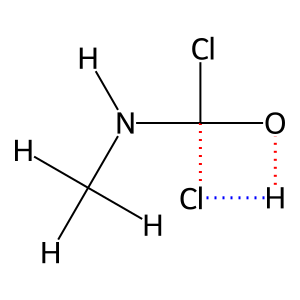

In [15]:
crg1_aminol_o = StereoCondensedReactionGraph(crg_aminol.product())
crg1_aminol_o.add_formed_bond(9,3)
crg1_aminol_o.add_broken_bond(9,8)
crg1_aminol_o.add_broken_bond(3,10)

rn.add(crg1_aminol_o)
crg1_aminol_o

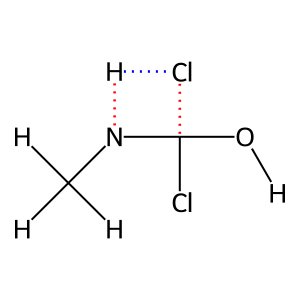

In [16]:
crg1_aminol_n = StereoCondensedReactionGraph(crg_aminol.product())

crg1_aminol_n.add_formed_bond(2,7)
crg1_aminol_n.add_broken_bond(0,2)
crg1_aminol_n.add_broken_bond(7,8)

rn.add(crg1_aminol_n)    
crg1_aminol_n


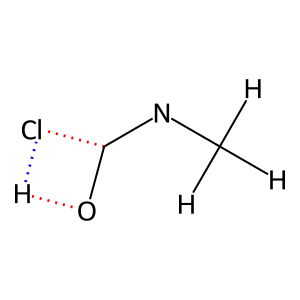

In [17]:
crg2_iminol = StereoCondensedReactionGraph(crg1_aminol_n.product().subgraph([a for a in crg1_aminol_n.atoms if a not in (2,7)]))

crg2_iminol.add_formed_bond(3,9)
crg2_iminol.add_broken_bond(8,9)
crg2_iminol.add_broken_bond(10, 3)

rn.add(crg2_iminol)

crg2_iminol

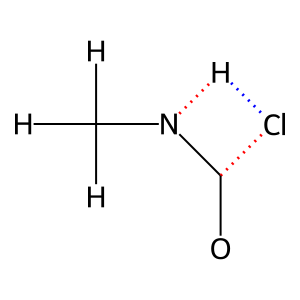

In [18]:
crg2 = StereoCondensedReactionGraph(crg1.product().subgraph([i for i in crg1.atoms if i not in (2,7)]))

crg2.add_formed_bond(3, 9)
crg2.add_broken_bond(0,3)
crg2.add_broken_bond(9,8)

rn.add(crg2.copy())

crg2

In [19]:
builder = build_builder_from_container(rn)#, skip_species=[MolGraph.from_rdmol(hcl_rdmol),
                                               #              MolGraph.from_rdmol(methylamine_rdmol),])
layout_opts = {'direction':'RIGHT','layered.spacing.nodeNodeBetweenLayers':10,'padding':10}
html = cybuilder_html(builder, layout="klay")#layout='layered', layout_options=layout_opts)
Path('html.html').resolve().write_text(html, encoding='utf-8')
print("done")

done


In [20]:
# Build aligned renderer and export aligned HTML
renderer = aligned_renderer_from_container(crg_cat_rn, align_reactions=True)
builder_aligned = build_builder_from_container(crg_cat_rn, view=renderer,
                                               skip_species=[MolGraph.from_rdmol(hcl_rdmol),
                                               MolGraph.from_rdmol(methylamine_rdmol)])
html_aligned = cybuilder_html(builder_aligned, layout="klay")
path_aligned = Path("methylamine_cat.html").resolve()
path_aligned.write_text(html_aligned, encoding="utf-8")
print("wrote", path_aligned)

NameError: name 'crg_cat_rn' is not defined